## AuxTel Mount fails - 18-Feb-21

In this notebook, investigate observed mount fails during the observing night 18-Feb-21

In [1]:
import sys, time, os, asyncio

from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from lsst.ts import salobj
from lsst.ts.observatory.control.auxtel.atcs import ATCS
from lsst.ts.observatory.control.auxtel.latiss import LATISS
from astropy.time import Time, TimeDelta
from astropy.coordinates import AltAz, ICRS, EarthLocation, Angle, FK5
import astropy.units as u
from lsst_efd_client import EfdClient
from lsst.daf.persistence import Butler

/opt/lsst/software/stack/conda/miniconda3-py38_4.9.2/envs/lsst-scipipe-0.4.1/lib/python3.8/site-packages/jose/backends/cryptography_backend.py:23: CryptographyDeprecationWarning: int_from_bytes is deprecated, use int.from_bytes instead
  from cryptography.utils import int_from_bytes, int_to_bytes


In [2]:
# Set Cerro Pachon location
location = EarthLocation.from_geodetic(lon=-70.747698*u.deg,
                                       lat=-30.244728*u.deg,
                                       height=2663.0*u.m)

In [3]:
# for tab completion to work in current notebook instance
%config IPCompleter.use_jedi = False

In [4]:
import logging
stream_handler = logging.StreamHandler(sys.stdout)
logger = logging.getLogger()
logger.addHandler(stream_handler)
logger.level = logging.DEBUG

In [5]:
# Get EFD client and bring in Lupton's unpacking code
client = EfdClient('summit_efd')

def merge_packed_time_series(packed_dataframe, base_field, stride=1, 
                             ref_timestamp_col="cRIO_timestamp", internal_time_scale="tai"):
    """Select fields that are time samples and unpack them into a dataframe.
            Parameters
            ----------
            packedDF : `pandas.DataFrame`
                packed data frame containing the desired data
            base_field :  `str`
                Base field name that will be expanded to query all
                vector entries.
            stride : `int`, optional
                Only use every stride value when unpacking.  Must be a factor
                of the number of packed values.
                (1 by default)
            ref_timestamp_col : `str`, optional
                Name of the field name to use to assign timestamps to unpacked
                vector fields (default is 'cRIO_timestamp').
            internal_time_scale : `str`, optional
                Time scale to use when converting times to internal formats
                ('tai' by default). Equivalent to EfdClient.internal_scale
        Returns
            -------
            result : `pandas.DataFrame`
                A `pandas.DataFrame` containing the results of the query.
            """
    
    packed_fields = [k for k in packed_dataframe.keys() if k.startswith(base_field)]
    packed_fields = sorted(packed_fields, key=lambda k: int(k[len(base_field):]))  # sort by pack ID
    npack = len(packed_fields)
    if npack%stride != 0:
        raise RuntimeError(f"Stride must be a factor of the number of packed fields: {stride} v. {npack}")
    packed_len = len(packed_dataframe)
    n_used = npack//stride   # number of raw fields being used
    output = np.empty(n_used*packed_len)
    times = np.empty_like(output, dtype=packed_dataframe[ref_timestamp_col][0])
    
    if packed_len == 1:
        dt = 0
    else:
        dt = (packed_dataframe[ref_timestamp_col][1] - packed_dataframe[ref_timestamp_col][0])/npack
    for i in range(0, npack, stride):
        i0 = i//stride
        output[i0::n_used] = packed_dataframe[f"{base_field}{i}"]
        times[i0::n_used] = packed_dataframe[ref_timestamp_col] + i*dt
     
    timestamps = Time(times, format='unix', scale=internal_time_scale).datetime64
    return pd.DataFrame({base_field:output, "times":times}, index=timestamps)

Starting new HTTPS connection (1): roundtable.lsst.codes:443
https://roundtable.lsst.codes:443 "GET /segwarides/ HTTP/1.1" 200 253
Starting new HTTPS connection (1): roundtable.lsst.codes:443
https://roundtable.lsst.codes:443 "GET /segwarides/creds/summit_efd HTTP/1.1" 200 92
Starting new HTTPS connection (1): influxdb-summit-efd.lsst.codes:443
https://influxdb-summit-efd.lsst.codes:443 "GET /health HTTP/1.1" 200 106


In [6]:
# Get the start and end times
REPO_DIR = '/readonly/lsstdata/auxtel/base/auxtel/oods/butler/repo'
butler = Butler(REPO_DIR)
expId1=2021021800699
starts = []
ends = []
for i in range(8):
    expId = expId1 + i
    exp = butler.get('raw', detector=0, expId=expId)
    mData = exp.getMetadata()
    tStart = mData['DATE-BEG']
    starts.append(tStart)
    tEnd = mData['DATE-END']
    ends.append(tEnd)
    print(tStart, tEnd, mData['EXPTIME'])

Checking for header correction file named LATISS-AT_O_20210218_000699.yaml
AT_O_20210218_000699: Forcing detector serial to ITL-3800C-068
AT_O_20210218_000699: Forcing SHUTTIME header to be None
Checking for header correction file named LATISS-AT_O_20210218_000699.yaml
AT_O_20210218_000699: Forcing detector serial to ITL-3800C-068
AT_O_20210218_000699: Forcing SHUTTIME header to be None


/home/craiglagegit/WORK/obs_base/python/lsst/obs/base/filters.py:92: FutureWarning: Call to deprecated function (or staticmethod) resetFilters. (Removed with no replacement (FilterLabels do not need to be reset). Will be removed after v22.) -- Deprecated since version v22.
  lsst.afw.image.utils.resetFilters()
/opt/lsst/software/stack/stack/miniconda3-py38_4.9.2-0.4.1/Linux64/afw/21.0.0-18-g1421380c6+e734d31160/python/lsst/afw/image/utils.py:58: FutureWarning: Replaced by FilterLabel. Will be removed after v22.
  Filter.reset()
/opt/lsst/software/stack/stack/miniconda3-py38_4.9.2-0.4.1/Linux64/afw/21.0.0-18-g1421380c6+e734d31160/python/lsst/afw/image/utils.py:59: FutureWarning: Removed with no replacement (but see lsst.afw.image.TransmissionCurve).Will be removed after v22.
  FilterProperty.reset()
/home/craiglagegit/WORK/obs_base/python/lsst/obs/base/filters.py:214: FutureWarning: Call to deprecated function (or staticmethod) defineFilter. (Removed with no replacement (but see lsst::a

Checking for header correction file named LATISS-AT_O_20210218_000699.yaml
AT_O_20210218_000699: Forcing detector serial to ITL-3800C-068
AT_O_20210218_000699: Forcing SHUTTIME header to be None
Checking for header correction file named LATISS-AT_O_20210218_000699.yaml
AT_O_20210218_000699: Forcing detector serial to ITL-3800C-068
AT_O_20210218_000699: Forcing SHUTTIME header to be None
Checking for header correction file named LATISS-AT_O_20210218_000699.yaml
AT_O_20210218_000699: Forcing detector serial to ITL-3800C-068
AT_O_20210218_000699: Forcing SHUTTIME header to be None
Checking for header correction file named LATISS-AT_O_20210218_000699.yaml
AT_O_20210218_000699: Forcing detector serial to ITL-3800C-068
AT_O_20210218_000699: Forcing SHUTTIME header to be None
Checking for header correction file named LATISS-AT_O_20210218_000699.yaml
AT_O_20210218_000699: Forcing detector serial to ITL-3800C-068
AT_O_20210218_000699: Forcing SHUTTIME header to be None
Checking for header corre

In [14]:
print(starts[0], ends[0])

2021-02-19T08:46:23.643 2021-02-19T08:46:25.888


In [15]:
t_end = Time('2021-02-19T08:47:42', scale='tai')
nsec = 81
mount_position = await client.select_time_series("lsst.sal.ATPtg.mount_positions", ['*'],
                                          t_end - TimeDelta(nsec, format='sec'), t_end)
ra = merge_packed_time_series(mount_position, 'ra', stride=1)
dec = merge_packed_time_series(mount_position, 'declination', stride=1)


200: SELECT * FROM "efd"."autogen"."lsst.sal.ATPtg.mount_positions" WHERE time >= '2021-02-19T08:46:21.000Z' AND time <= '2021-02-19T08:47:42.000Z'


Assigning font /b'F1' = '/opt/lsst/software/stack/conda/miniconda3-py38_4.9.2/envs/lsst-scipipe-0.4.1/lib/python3.8/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf'
findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0.
findfont: score(<Font 'STIXSizeFourSym' (STIXSizFourSymReg.ttf) normal normal 400 normal>) = 10.05
findfont: score(<Font 'cmex10' (cmex10.ttf) normal normal 400 normal>) = 10.05
findfont: score(<Font 'DejaVu Sans Mono' (DejaVuSansMono-Bold.ttf) normal normal 700 normal>) = 10.335
findfont: score(<Font 'STIXSizeThreeSym' (STIXSizThreeSymReg.ttf) normal normal 400 normal>) = 10.05
findfont: score(<Font 'STIXNonUnicode' (STIXNonUni.ttf) normal normal 400 normal>) = 10.05
findfont: score(<Font 'STIXGeneral' (STIXGeneralBolIta.ttf) italic normal 700 normal>) = 11.335
findfont: score(<Font 'cmss10' (cmss10.ttf) normal normal 400 normal>) = 10.05
findfont: score(<Font 'STIXSizeTwoSym' (STIXSizTwoSymReg.ttf) normal normal 4

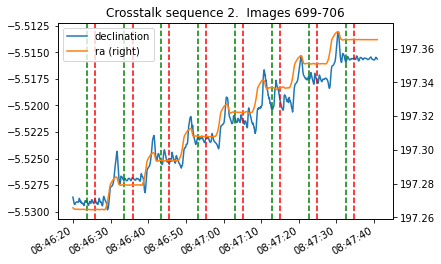

In [18]:
# The time axis looks correct. 
ax = dec['declination'].plot(legend=True)
ra['ra'].plot(legend=True, secondary_y=True)
for i in range(8):
    ax.axvline(starts[i], color="green", linestyle="--")
    ax.axvline(ends[i], color="red", linestyle="--")
plt.title("Crosstalk sequence 2.  Images 699-706")
plt.savefig("/home/craiglagegit/DATA/Second_Crosstalk_Sequence_18Feb21.pdf")

In [ ]:
ra_vals = np.array(ra.values.tolist())[:,0]
dec_vals = np.array(dec.values.tolist())[:,0]
ra_mean = np.mean(ra_vals)
dec_mean = np.mean(dec_vals)
# Errors in arcsec
ra_rms = np.sqrt(np.mean((ra_vals - ra_mean)**2)) * 3600.0 
dec_rms = np.sqrt(np.mean((dec_vals - dec_mean)**2)) * 3600.0 
ra_mean_error = abs(ra_dec.ra.value - ra_mean) * 3600
dec_mean_error = abs(ra_dec.dec.value - dec_mean) * 3600
print(f"RA rms error= {ra_rms} arcseconds. Dec rms error= {dec_rms} arcseconds.")
print(f"RA mean error = {ra_mean_error} arcseconds. Dec mean error = {dec_mean_error} arcseconds.")


In [ ]:
t_start = Time(tStart, scale='tai')
t_end = Time(tEnd, scale='tai')
mount_position = await client.select_time_series("lsst.sal.ATMCS.mount_AzEl_Encoders", ['*'],
                                          t_start, t_end)
nasmyth_position = await client.select_time_series("lsst.sal.ATMCS.mount_Nasmyth_Encoders", ['*'],
                                          t_start, t_end)
az = merge_packed_time_series(mount_position, 'azimuthCalculatedAngle', stride=1)
el = merge_packed_time_series(mount_position, 'elevationCalculatedAngle', stride=1)
rot = merge_packed_time_series(nasmyth_position, 'nasmyth2CalculatedAngle', stride=1)

In [ ]:
az_vals = np.array(az.values.tolist())[:,0]
el_vals = np.array(el.values.tolist())[:,0]
rot_vals = np.array(rot.values.tolist())[:,0]
times = np.array(az.values.tolist())[:,1]
times = times - times [0]

# Fit with a quadratic
az_fit = np.polyfit(times, az_vals, 2)
el_fit = np.polyfit(times, el_vals, 2)
rot_fit = np.polyfit(times, rot_vals, 2)

az_model = az_fit[0] * times * times + az_fit[1] * times + az_fit[2]
el_model = el_fit[0] * times * times + el_fit[1] * times + el_fit[2]
rot_model = rot_fit[0] * times * times + rot_fit[1] * times + rot_fit[2]

# Errors in arcseconds
az_error = (az_vals - az_model) * 3600
el_error = (el_vals - el_model) * 3600
rot_error = (rot_vals - rot_model) * 3600

# Calculate RMS
az_rms = np.sqrt(np.mean(az_error * az_error))
el_rms = np.sqrt(np.mean(el_error * el_error))
rot_rms = np.sqrt(np.mean(rot_error * rot_error))

In [ ]:
fig = plt.figure(figsize = (16,8))
plt.suptitle(f"Mount Tracking {expId}", fontsize = 18)
plt.subplot(3,2,1)
ax1 = az['azimuthCalculatedAngle'].plot(legend=True, color='red')
ax1.axvline(tStart, color="red", linestyle="--")
ax1.set_xticks([])
plt.subplot(3,2,3)
ax3 = el['elevationCalculatedAngle'].plot(legend=True, color='green')
ax3.axvline(tStart, color="red", linestyle="--")
ax3.set_xticks([])
plt.subplot(3,2,5)
ax5 = rot['nasmyth2CalculatedAngle'].plot(legend=True, color='blue')
ax5.axvline(tStart, color="red", linestyle="--")

plt.subplot(3,2,2)
plt.plot(times, az_error, color='red')
plt.title(f"Azimuth RMS error = {az_rms:.2f} arcseconds")
plt.ylim(-10.0,10.0)
plt.xticks([])
plt.subplot(3,2,4)
plt.plot(times, el_error, color='green')
plt.title(f"Elevation RMS error = {el_rms:.2f} arcseconds")
plt.ylim(-10.0,10.0)
plt.xticks([])
plt.subplot(3,2,6)
plt.plot(times, rot_error, color='blue')
plt.title(f"Nasmyth RMS error = {rot_rms:.2f} arcseconds")
plt.ylim(-10.0,10.0)

plt.savefig(f"/home/craiglagegit/DATA/Mount_Errors_{expId}_20Feb21.pdf")